In [229]:
import os
import numpy as np
import matplotlib.pyplot as plot
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from matplotlib.colors import Normalize

print(os.getcwd())
!jupyter labextension install jupyterlab-plotly

/vast/palmer/home.grace/kd766
(Deprecated) Installing extensions with the jupyter labextension install command is now deprecated and will be removed in a future major version of JupyterLab.

Users should manage prebuilt extensions with package managers like pip and conda, and extension authors are encouraged to distribute their extensions as prebuilt packages 
/home/kd766/project/.conda/envs/quorum/lib/python3.12/site-packages/jupyterlab/debuglog.py:54: UserWarning: An error occurred.
  warnings.warn("An error occurred.")
/home/kd766/project/.conda/envs/quorum/lib/python3.12/site-packages/jupyterlab/debuglog.py:55: UserWarning: ValueError: Please install Node.js and npm before continuing installation. You may be able to install Node.js from your package manager, from conda, or directly from the Node.js website (https://nodejs.org).
  warnings.warn(msg[-1].strip())
/home/kd766/project/.conda/envs/quorum/lib/python3.12/site-packages/jupyterlab/debuglog.py:56: UserWarning: See the log fil

In [268]:
def imshow3d(ax, array, value_direction='z', pos=0, norm=None, cmap=None):
    """
    Display a 2D array as a  color-coded 2D image embedded in 3d.

    The image will be in a plane perpendicular to the coordinate axis *value_direction*.

    Parameters
    ----------
    ax : Axes3D
        The 3D Axes to plot into.
    array : 2D numpy array
        The image values.
    value_direction : {'x', 'y', 'z'}
        The axis normal to the image plane.
    pos : float
        The numeric value on the *value_direction* axis at which the image plane is
        located.
    norm : `~matplotlib.colors.Normalize`, default: Normalize
        The normalization method used to scale scalar data. See `imshow()`.
    cmap : str or `~matplotlib.colors.Colormap`, default: :rc:`image.cmap`
        The Colormap instance or registered colormap name used to map scalar data
        to colors.
    """
    if norm is None:
        norm = Normalize()
    colors = plot.get_cmap(cmap)(array)

    if value_direction == 'x':
        nz, ny = array.shape
        zi, yi = np.mgrid[0:nz + 1, 0:ny + 1]
        xi = np.full_like(yi, pos)
    elif value_direction == 'y':
        nx, nz = array.shape
        xi, zi = np.mgrid[0:nx + 1, 0:nz + 1]
        yi = np.full_like(zi, pos)
    elif value_direction == 'z':
        ny, nx = array.shape
        yi, xi = np.mgrid[0:ny + 1, 0:nx + 1]
        zi = np.full_like(xi, pos)
    else:
        raise ValueError(f"Invalid value_direction: {value_direction!r}")
    surf = ax.plot_surface(xi, yi, zi, rstride=1, cstride=1, facecolors=colors, cmap=cmap, vmin=0, vmax=0.8, shade=False)
    return surf

## Graded Density - No Negative Feedback

In [269]:
clouds_all = np.load("quorum-sensing/notebooks/graded_seeding/noneg_gradedseeding_clouds_all.npy")
levels_all = np.load("quorum-sensing/notebooks/graded_seeding/noneg_gradedseeding_levels_all.npy")
cloud_to_plot = clouds_all[-1, :, :]
level_to_plot = levels_all[-1, :, :]
density_distribution = np.vstack([x*np.ones((30, 60)) for x in [0.05*x for x in range(1, 8)]])
print(density_distribution)

[[0.05 0.05 0.05 ... 0.05 0.05 0.05]
 [0.05 0.05 0.05 ... 0.05 0.05 0.05]
 [0.05 0.05 0.05 ... 0.05 0.05 0.05]
 ...
 [0.35 0.35 0.35 ... 0.35 0.35 0.35]
 [0.35 0.35 0.35 ... 0.35 0.35 0.35]
 [0.35 0.35 0.35 ... 0.35 0.35 0.35]]


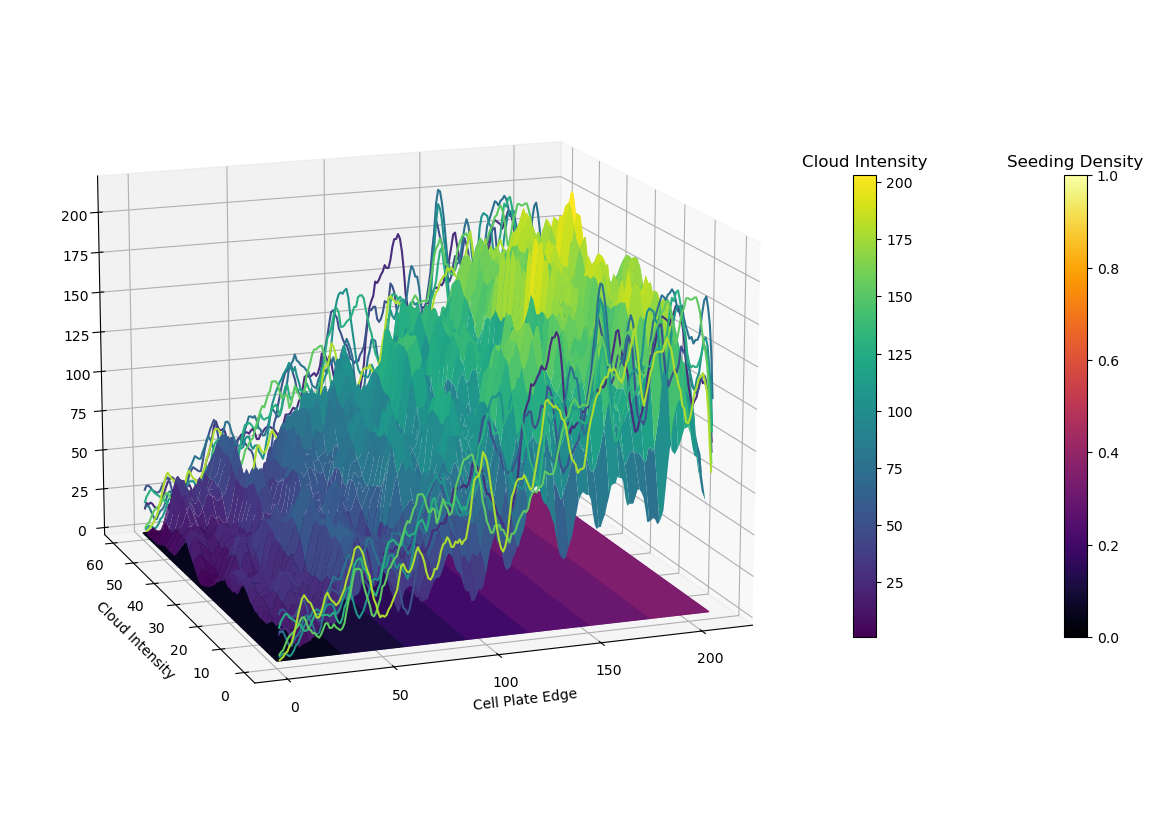

In [282]:
X, Y = np.meshgrid(np.arange(1, cloud_to_plot.shape[0]+1, 1), np.arange(1, cloud_to_plot.shape[1]+1, 1))
norm = Normalize()

fig = plot.figure(figsize=(16, 12))
ax1 = fig.add_subplot(111, projection='3d')
ax1.view_init(elev=15, azim=250)
surf = ax1.plot_surface(X, Y, cloud_to_plot.T, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=0, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=60, cmap='viridis')
base = imshow3d(ax1, density_distribution.T, value_direction='z', cmap='inferno')
# add colorbars
density_cbar = plot.colorbar(base, shrink=0.5)
density_cbar.ax.set_title("Seeding Density")
cntr_cbar = plot.colorbar(surf, shrink=0.5)
cntr_cbar.ax.set_title("Cloud Intensity")
# set axes
ax1.set_xlabel('Cell Plate Edge')
ax1.set_ylabel('Cell Plate Edge')
ax1.set_ylabel('Cloud Intensity')
# show plot
plot.show()

In [158]:
fig = go.Figure(data=[go.Surface(z=cloud_to_plot)])
fig.update_layout(title=dict(text='Graded Seeding - Cloud Intensities'), autosize=True,
                  width=500, height=500)
fig.show()

## Graded Density - With Negative Feedback

In [284]:
clouds_all = np.load("quorum-sensing/notebooks/graded_seeding/gradedseeding_clouds_all.npy")
levels_all = np.load("quorum-sensing/notebooks/graded_seeding/gradedseeding_levels_all.npy")
cloud_to_plot = clouds_all[-1, :, :]
level_to_plot = levels_all[-1, :, :]
density_distribution = np.vstack([x*np.ones((30, 60)) for x in [0.05*x for x in range(1, 8)]])
print(density_distribution.shape)

(210, 60)


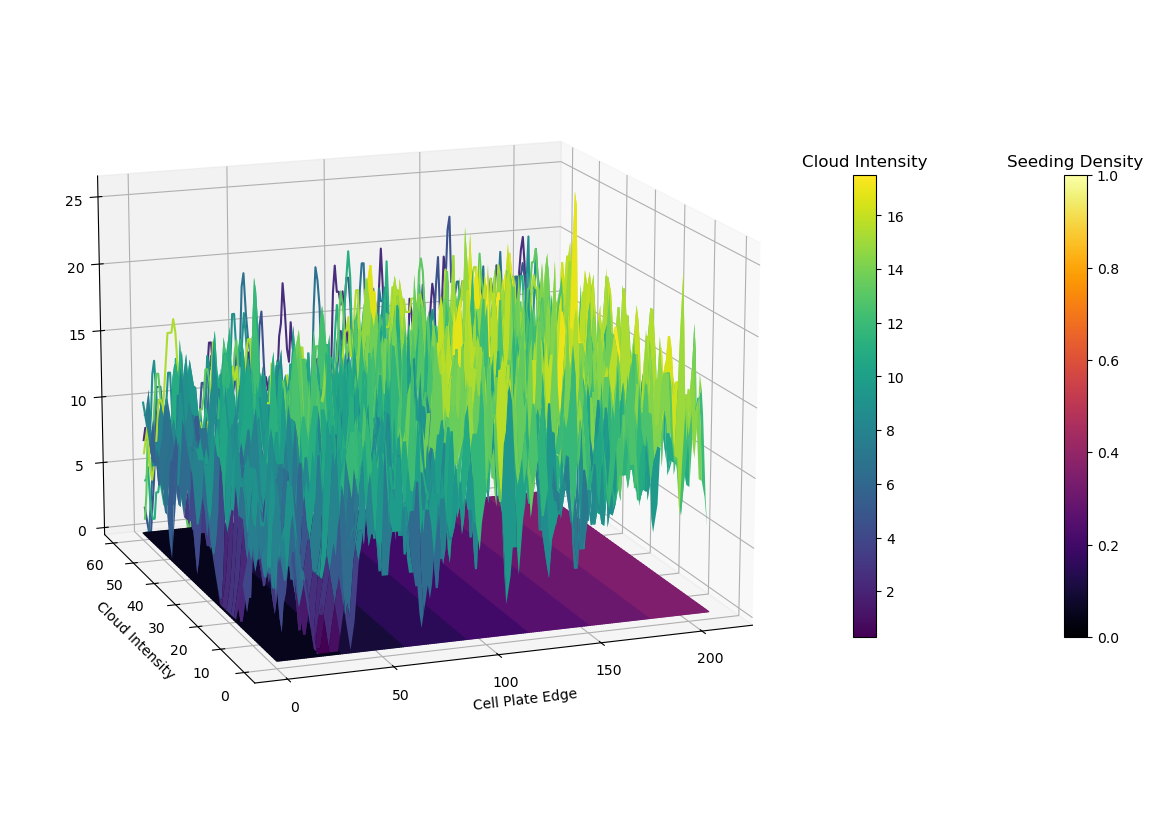

In [295]:
X, Y = np.meshgrid(np.arange(1, cloud_to_plot.shape[0]+1, 1), np.arange(1, cloud_to_plot.shape[1]+1, 1))
norm = Normalize()

fig = plot.figure(figsize=(16, 12))
ax1 = fig.add_subplot(111, projection='3d')
ax1.view_init(elev=15, azim=250)
surf = ax1.plot_surface(X, Y, cloud_to_plot.T, cmap='viridis')
contour = ax1.contour(X, Y, cloud_to_plot.T, zdir='y', offset=60, cmap='viridis')
base = imshow3d(ax1, density_distribution.T, value_direction='z', cmap='inferno')
# add colorbars
density_cbar = plot.colorbar(base, shrink=0.5)
density_cbar.ax.set_title("Seeding Density")
cntr_cbar = plot.colorbar(surf, shrink=0.5)
cntr_cbar.ax.set_title("Cloud Intensity")
# set axes
ax1.set_xlabel('Cell Plate Edge')
ax1.set_ylabel('Cell Plate Edge')
ax1.set_ylabel('Cloud Intensity')
# show plot
plot.show()

In [161]:
fig = go.Figure(data=[
    go.Surface(z=cloud_to_plot)])
fig.update_layout(title=dict(text='Graded Seeding - Cloud Intensities'), autosize=False,
                  width=500, height=500,
                  margin=dict(l=65, r=50, b=65, t=90))
fig.show()